Convoluted audio saved as 'output_convoluted.wav'.


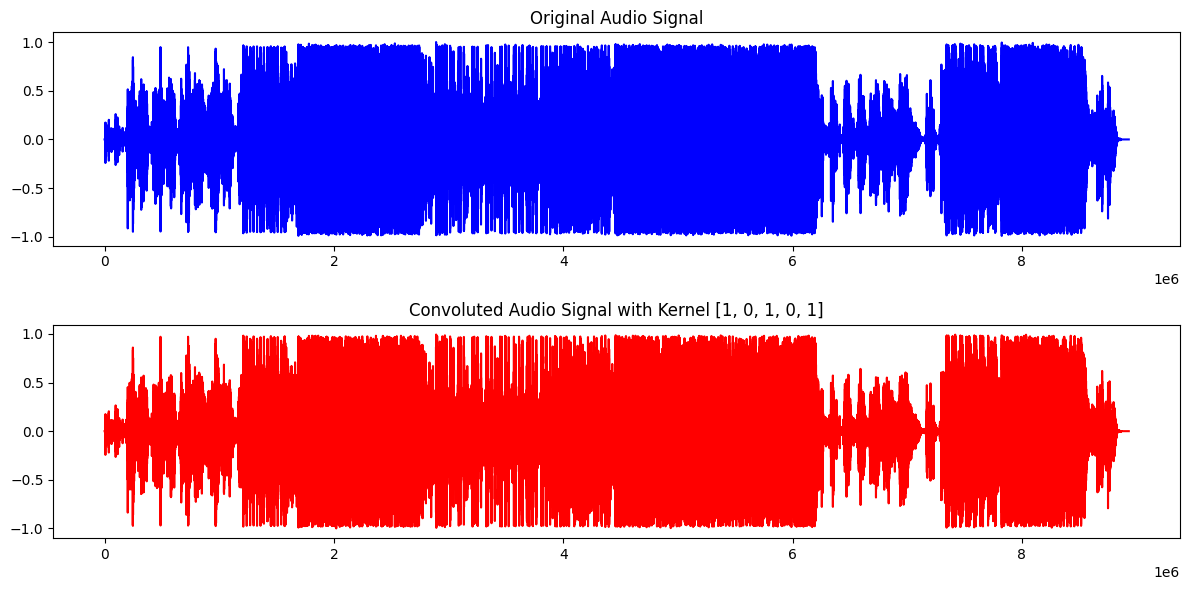

In [1]:
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
# Load MP3 file
audio = AudioSegment.from_mp3("Rachel_Platten_Fight_Song.mp3")
# Convert to mono and extract raw samples
audio = audio.set_channels(1)
samples = np.array(audio.get_array_of_samples()).astype(np.float32)
# Define convolution kernel
kernel = np.array([1, 0, 1, 0, 1], dtype=np.float32)
#kernel=np.array([1,-1,0,1,1], dtype=np.float32),
# Perform convolution
convoluted = convolve(samples, kernel, mode='same')
# Normalize to int16 range for saving
convoluted = convoluted / np.max(np.abs(convoluted)) # Normalize to [-1, 1]
convoluted_int16 = (convoluted * 32767).astype(np.int16) # Scale toint16
# Save as WAV using PyDub
convoluted_audio = AudioSegment(
    convoluted_int16.tobytes(),
    frame_rate=audio.frame_rate,
    sample_width=2, # 16-bit samples = 2 bytes
    channels=1
)
# Export to file
convoluted_audio.export("output_convoluted.wav", format="wav")
print("Convoluted audio saved as 'output_convoluted.wav'.")
# Plot original and convoluted signals (optional)
samples_norm = samples / np.max(np.abs(samples))
convoluted_norm = convoluted
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(samples_norm, color='blue')
plt.title("Original Audio Signal")
plt.subplot(2, 1, 2)
plt.plot(convoluted_norm, color='red')

plt.title("Convoluted Audio Signal with Kernel [1, 0, 1, 0, 1]")
plt.tight_layout()
plt.show()

In [2]:
pip install pydub


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Sampling Frequency : 44100


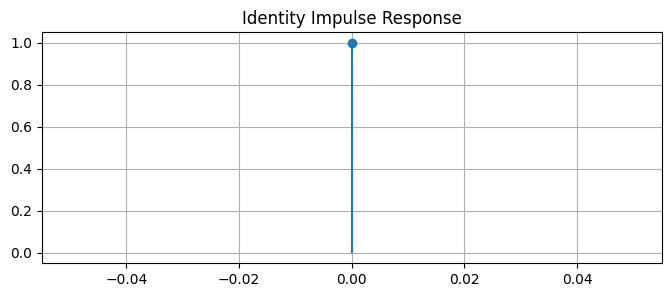

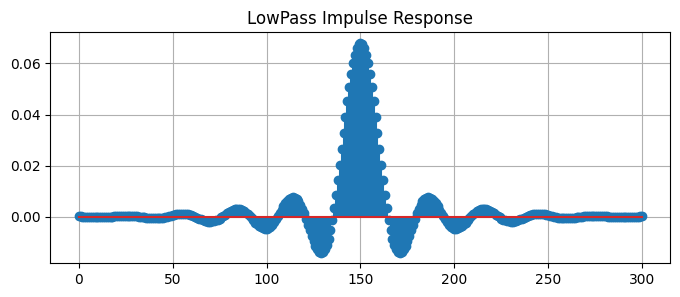

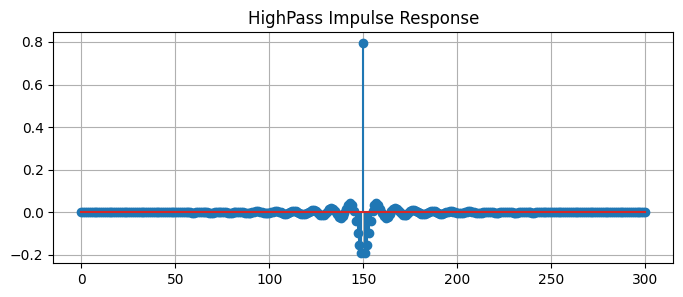

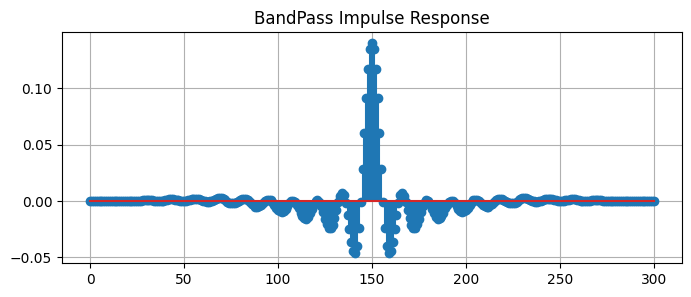

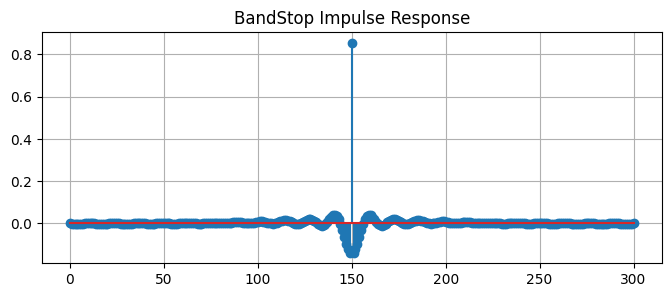

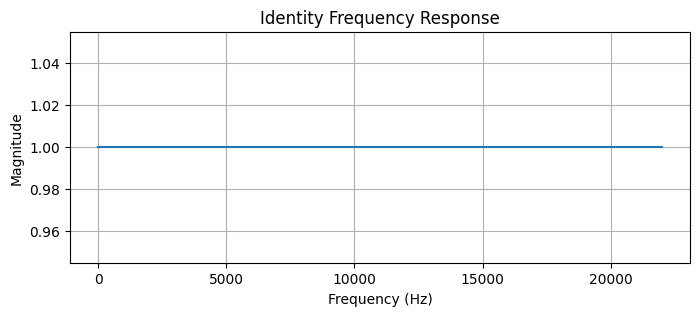

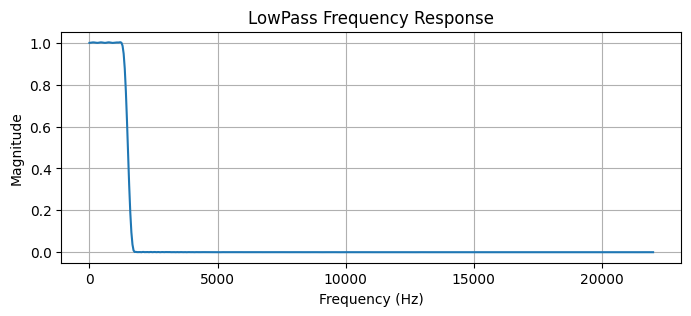

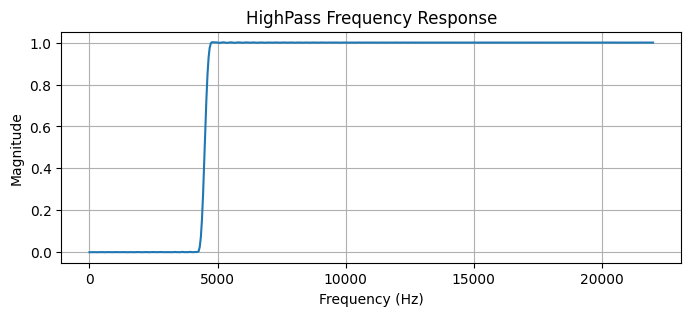

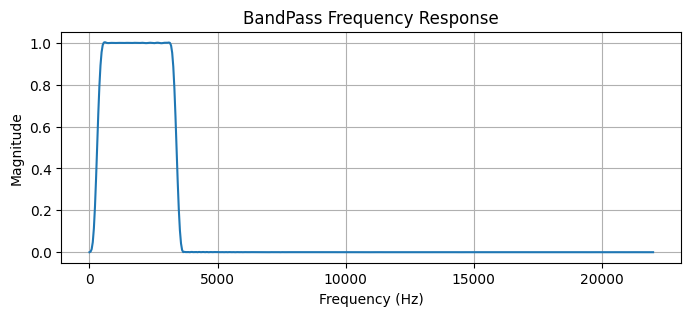

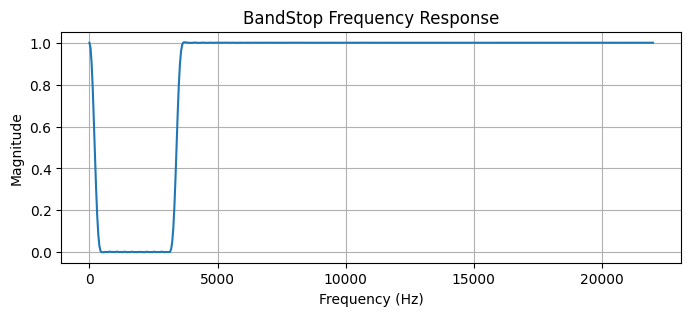

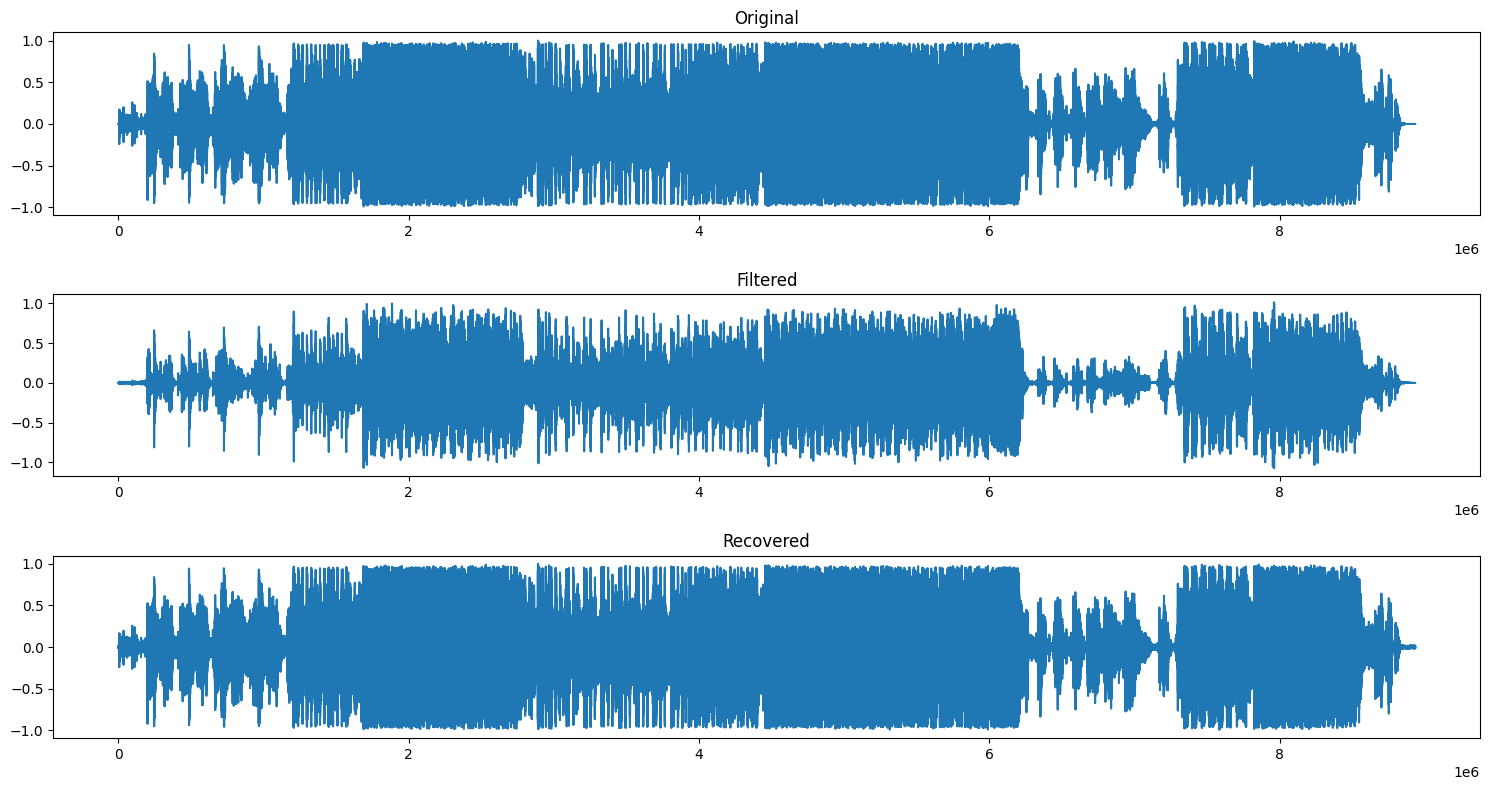

In [3]:
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, freqz
from scipy.fft import fft, ifft

file_path = r"Rachel_Platten_Fight_Song.mp3"

audio = AudioSegment.from_file(file_path)
audio = audio.set_channels(1)

samples = np.array(audio.get_array_of_samples()).astype(np.float32)

samples /= np.max(np.abs(samples))

fs = audio.frame_rate

print("Sampling Frequency :", fs)



def hamming_window(N):

    n = np.arange(N)

    return 0.54 - 0.46*np.cos(2*np.pi*n/(N-1))


def lowpass(fc, fs, N):

    fc = fc/fs

    n = np.arange(N)

    M = (N-1)/2

    h = 2*fc*np.sinc(2*fc*(n-M))

    h *= hamming_window(N)

    h /= np.sum(h)

    return h


def highpass(fc, fs, N):

    h = lowpass(fc, fs, N)

    h = -h

    h[(N-1)//2] += 1

    return h



def bandpass(fc1, fc2, fs, N):

    h1 = lowpass(fc2, fs, N)

    h2 = lowpass(fc1, fs, N)

    return h1-h2


def bandstop(fc1, fc2, fs, N):

    h = bandpass(fc1,fc2,fs,N)

    h = -h

    h[(N-1)//2]+=1

    return h


N = 301

identity = np.array([1.0])
low = lowpass(1500,fs,N)
band = bandpass(300,3400,fs,N)
stop = bandstop(200,3400,fs,N)
high = highpass(4500,fs,N)
filters = {

    "Identity":identity,

    "LowPass":low,

    "HighPass":high,

    "BandPass":band,

    "BandStop":stop

}

for name,h in filters.items():

    plt.figure(figsize=(8,3))

    plt.stem(h)

    plt.title(name+" Impulse Response")

    plt.grid()

    plt.show()


for name,h in filters.items():

    w,H = freqz(h)

    plt.figure(figsize=(8,3))

    plt.plot(w*fs/(2*np.pi),np.abs(H))

    plt.title(name+" Frequency Response")

    plt.xlabel("Frequency (Hz)")

    plt.ylabel("Magnitude")

    plt.grid()

    plt.show()


for name,h in filters.items():

    filtered = convolve(samples,h,mode="same")

    filtered /= np.max(np.abs(filtered))

    filtered16 = (filtered*32767).astype(np.int16)

    AudioSegment(

        filtered16.tobytes(),

        frame_rate=fs,

        sample_width=2,

        channels=1

    ).export(f"{name}.wav",format="wav")


for name,h in filters.items():

    filtered = convolve(samples,h,mode="same")

    Nfft = len(filtered)

    H = fft(h,Nfft)

    Y = fft(filtered)

    eps = 1e-6

    recovered = np.real(ifft(Y/(H+eps)))

    recovered /= np.max(np.abs(recovered))

    recovered16 = (recovered*32767).astype(np.int16)

    AudioSegment(

        recovered16.tobytes(),

        frame_rate=fs,

        sample_width=2,

        channels=1

    ).export(f"{name}_Recovered.wav",format="wav")


for name,h in filters.items():

    filtered = convolve(samples,h,mode="same")

    Nfft = len(filtered)

    H = fft(h,Nfft)

    Y = fft(filtered)

    eps = 1e-6

    recovered = np.real(ifft(Y/(H+eps)))

    recovered /= np.max(np.abs(recovered))

    recovered16 = (recovered*32767).astype(np.int16)

    AudioSegment(

        recovered16.tobytes(),

        frame_rate=fs,

        sample_width=2,

        channels=1

    ).export(f"{name}_Recovered.wav",format="wav")

plt.figure(figsize=(15,8))

plt.subplot(311)
plt.plot(samples)
plt.title("Original")

plt.subplot(312)
plt.plot(filtered)
plt.title("Filtered")

plt.subplot(313)
plt.plot(recovered)
plt.title("Recovered")

plt.tight_layout()
plt.show()